In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
t2012 = pd.read_csv(
    "/mnt/user-data/uploads/Tabela5-sem_emprego_2012.csv",
    sep=";",
    decimal=",",
)

t2026 = pd.read_csv(
    "/mnt/user-data/uploads/Tabela5-sem_emprego_2026.csv",
    sep=";",
    decimal=",",
)

In [3]:
t2012 = t2012.rename(columns={
    "Desocupados - homens (2012 T1)": "homens_2012",
    "Desocupados - mulheres (2012 T1)": "mulheres_2012",
})

t2026 = t2026.rename(columns={
    "Desocupados - homens (2026 T1)": "homens_2026",
    "Desocupados - mulheres (2026 T1)": "mulheres_2026",
})

In [4]:
comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [5]:
ordem = comp.sort_values("mulheres_2026")["Estado"]

In [6]:
longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})
longo

,Sigla,Código,Estado,Ano,Participacao_mulheres
0,AC,12,Acre,2012 T1,54.7
1,AL,27,Alagoas,2012 T1,55.3
2,AM,13,Amazonas,2012 T1,52.5
3,AP,16,Amapá,2012 T1,51.9
4,BA,29,Bahia,2012 T1,56.2
5,CE,23,Ceará,2012 T1,48.9
6,DF,53,Distrito Federal,2012 T1,59.0
7,ES,32,Espírito Santo,2012 T1,53.6
8,GO,52,Goiás,2012 T1,59.0
9,MA,21,Maranhão,2012 T1,52.8


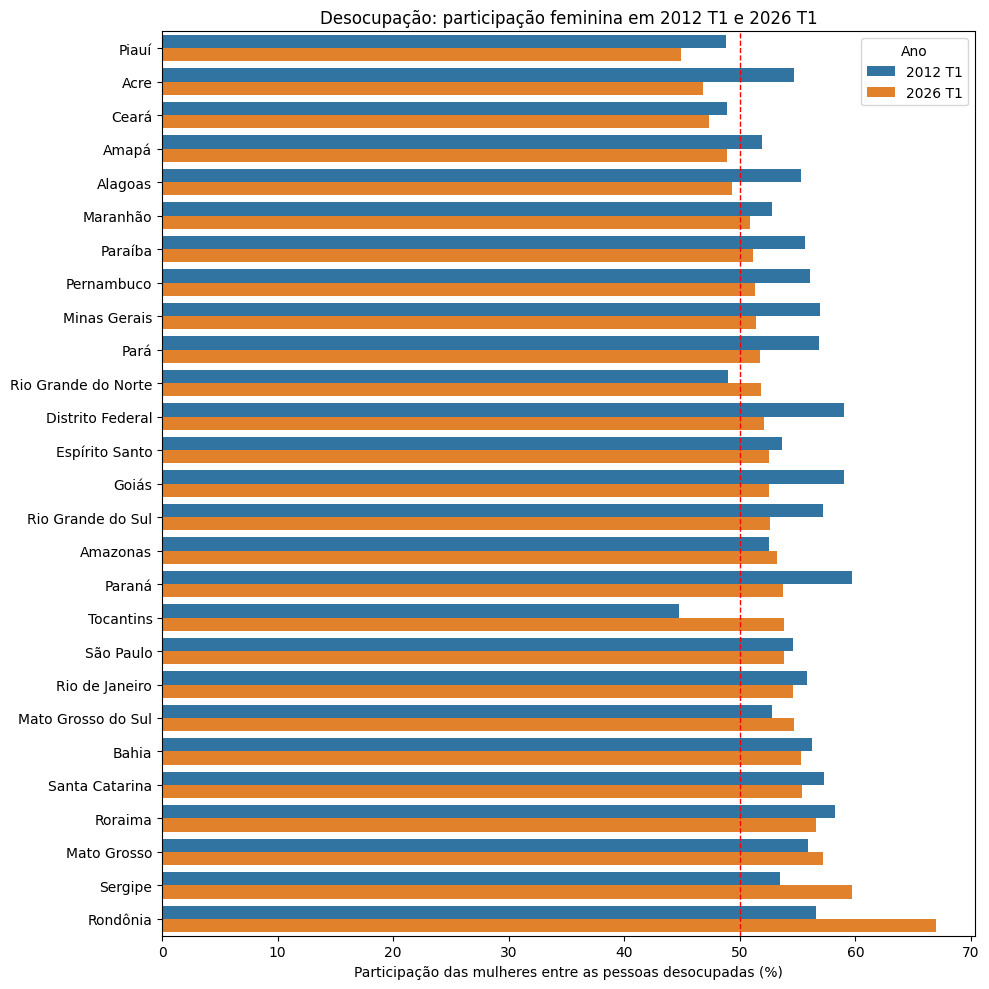

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)

ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Ano")
fig.tight_layout()
plt.show()